# **Introduction**

The degradation that can occur to aircraft parts over the course of their lifetime directly impacts both their performance and reliability. In order to provide the necessary maintenance behavior, this machine learning research will be focused on providing a framework for predicting the aircraft's remaining usable life (RUL) based on the whole life cycle data. Using the NASA C-MAPSS data set is implemented and tested to determine the engine lifetime.

Tracking and predicting the progression of damage in aircraft engine turbo machinery has some roots in the work of Kurosaki. They estimate the efficiency and the flow rate deviation of the compressor and the turbine based on operational data, and utilize this information for fault detection purposes.

<div style="width:100%;text-align: center;"><img src="https://i.postimg.cc/ZqdZ56mW/turbo-jet-engine-diagram.jpg" width="500px" height="500px"></div>

An important requirement for the damage modeling process was the availability of a suitable system model that allows input variations of health related parameters and recording of the resulting output sensor measurements. The recently released C-MAPSS (Commercial Modular Aero- Propulsion System Simulation) meets these requirements and was chosen for this work.
C-MAPSS is a tool for simulating a realistic large commercial turbofan engine.

A layout showing various modules and their connections as modeled in the simulation.

A low pressure compressor (LPC) and high pressure compressor (HPC) supply compressed high temperature, high pressure gases to the combustor. Low pressure turbine (LPT) can decelerate and pressurize air to improve the chemical energy conversion efficiency of aviation kerosene. High pressure turbines (HPT) generate mechanical energy by using high temperature and high pressure gas strike turbine blades. Low-pressure rotor (N1), high-pressure rotor (N2), and nozzle guarantee the combustion efficiency of the engine.

Our main focus will be on accurately recording low RUL values to prevent putting the engine at danger and forecasting the RUL of the turbofan engine while accounting for HPC failure.
Data analysis, data visualization and LSTM will all be covered in this notebook.

In [1]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from pylab import rcParams
import math
import xgboost
import time
from tqdm import tqdm
import keras.models
import keras.layers
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras import layers
import warnings
from keras import backend as K

warnings.simplefilter('ignore')

# set deterministic configurations
np.random.seed(83)
tf.random.set_seed(83)

In [2]:
data_train = pd.read_csv("/kaggle/input/nasa-cmaps/CMaps/train_FD001.txt",sep=" ",header=None)
data_test = pd.read_csv("/kaggle/input/nasa-cmaps/CMaps/test_FD001.txt",sep=" ",header=None)
data_RUL = pd.read_csv("/kaggle/input/nasa-cmaps/CMaps/RUL_FD001.txt",sep=" ",header=None)

train_copy = data_train
test_copy = data_test

In [3]:
data_train

,0,1,2,3,4,5,6,7,8,9,...,18,19,20,21,22,23,24,25,26,27
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190,NaN,NaN
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236,NaN,NaN
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442,NaN,NaN
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739,NaN,NaN
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20626,100,196,-0.0004,-0.0003,100.0,518.67,643.49,1597.98,1428.63,14.62,...,8137.60,8.4956,0.03,397,2388,100.0,38.49,22.9735,NaN,NaN
20627,100,197,-0.0016,-0.0005,100.0,518.67,643.54,1604.50,1433.58,14.62,...,8136.50,8.5139,0.03,395,2388,100.0,38.30,23.1594,NaN,NaN
20628,100,198,0.0004,0.0000,100.0,518.67,643.42,1602.46,1428.18,14.62,...,8141.05,8.5646,0.03,398,2388,100.0,38.44,22.9333,NaN,NaN
20629,100,199,-0.0011,0.0003,100.0,518.67,643.23,1605.26,1426.53,14.62,...,8139.29,8.5389,0.03,395,2388,100.0,38.29,23.0640,NaN,NaN


In [4]:
data_test

,0,1,2,3,4,5,6,7,8,9,...,18,19,20,21,22,23,24,25,26,27
0,1,1,0.0023,0.0003,100.0,518.67,643.02,1585.29,1398.21,14.62,...,8125.55,8.4052,0.03,392,2388,100.0,38.86,23.3735,NaN,NaN
1,1,2,-0.0027,-0.0003,100.0,518.67,641.71,1588.45,1395.42,14.62,...,8139.62,8.3803,0.03,393,2388,100.0,39.02,23.3916,NaN,NaN
2,1,3,0.0003,0.0001,100.0,518.67,642.46,1586.94,1401.34,14.62,...,8130.10,8.4441,0.03,393,2388,100.0,39.08,23.4166,NaN,NaN
3,1,4,0.0042,0.0000,100.0,518.67,642.44,1584.12,1406.42,14.62,...,8132.90,8.3917,0.03,391,2388,100.0,39.00,23.3737,NaN,NaN
4,1,5,0.0014,0.0000,100.0,518.67,642.51,1587.19,1401.92,14.62,...,8129.54,8.4031,0.03,390,2388,100.0,38.99,23.4130,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13091,100,194,0.0049,0.0000,100.0,518.67,643.24,1599.45,1415.79,14.62,...,8213.28,8.4715,0.03,394,2388,100.0,38.65,23.1974,NaN,NaN
13092,100,195,-0.0011,-0.0001,100.0,518.67,643.22,1595.69,1422.05,14.62,...,8210.85,8.4512,0.03,395,2388,100.0,38.57,23.2771,NaN,NaN
13093,100,196,-0.0006,-0.0003,100.0,518.67,643.44,1593.15,1406.82,14.62,...,8217.24,8.4569,0.03,395,2388,100.0,38.62,23.2051,NaN,NaN
13094,100,197,-0.0038,0.0001,100.0,518.67,643.26,1594.99,1419.36,14.62,...,8220.48,8.4711,0.03,395,2388,100.0,38.66,23.2699,NaN,NaN


In [5]:
data_RUL

,0,1
0,112,NaN
1,98,NaN
2,69,NaN
3,82,NaN
4,91,NaN
...,...,...
95,137,NaN
96,82,NaN
97,59,NaN
98,117,NaN


In [6]:
data_train.drop(columns=[26,27],inplace=True)
data_test.drop(columns=[26,27],inplace=True)
data_RUL.drop(columns=[1],inplace=True)

In [7]:
columns_train = ['unit_ID','cycles','setting_1','setting_2','setting_3','T2','T24','T30','T50','P2','P15','P30','Nf',
           'Nc','epr','Ps30','phi','NRf','NRc','BPR','farB','htBleed','Nf_dmd','PCNfR_dmd','W31','W32' ]
data_train.columns = columns_train
data_train.describe()

,unit_ID,cycles,setting_1,setting_2,setting_3,T2,T24,T30,T50,P2,...,phi,NRf,NRc,BPR,farB,htBleed,Nf_dmd,PCNfR_dmd,W31,W32
count,20631.000000,20631.000000,20631.000000,20631.000000,20631.0,20631.00,20631.000000,20631.000000,20631.000000,2.063100e+04,...,20631.000000,20631.000000,20631.000000,20631.000000,2.063100e+04,20631.000000,20631.0,20631.0,20631.000000,20631.000000
mean,51.506568,108.807862,-0.000009,0.000002,100.0,518.67,642.680934,1590.523119,1408.933782,1.462000e+01,...,521.413470,2388.096152,8143.752722,8.442146,3.000000e-02,393.210654,2388.0,100.0,38.816271,23.289705
std,29.227633,68.880990,0.002187,0.000293,0.0,0.00,0.500053,6.131150,9.000605,1.776400e-15,...,0.737553,0.071919,19.076176,0.037505,1.387812e-17,1.548763,0.0,0.0,0.180746,0.108251
min,1.000000,1.000000,-0.008700,-0.000600,100.0,518.67,641.210000,1571.040000,1382.250000,1.462000e+01,...,518.690000,2387.880000,8099.940000,8.324900,3.000000e-02,388.000000,2388.0,100.0,38.140000,22.894200
25%,26.000000,52.000000,-0.001500,-0.000200,100.0,518.67,642.325000,1586.260000,1402.360000,1.462000e+01,...,520.960000,2388.040000,8133.245000,8.414900,3.000000e-02,392.000000,2388.0,100.0,38.700000,23.221800
50%,52.000000,104.000000,0.000000,0.000000,100.0,518.67,642.640000,1590.100000,1408.040000,1.462000e+01,...,521.480000,2388.090000,8140.540000,8.438900,3.000000e-02,393.000000,2388.0,100.0,38.830000,23.297900
75%,77.000000,156.000000,0.001500,0.000300,100.0,518.67,643.000000,1594.380000,1414.555000,1.462000e+01,...,521.950000,2388.140000,8148.310000,8.465600,3.000000e-02,394.000000,2388.0,100.0,38.950000,23.366800
max,100.000000,362.000000,0.008700,0.000600,100.0,518.67,644.530000,1616.910000,1441.490000,1.462000e+01,...,523.380000,2388.560000,8293.720000,8.584800,3.000000e-02,400.000000,2388.0,100.0,39.430000,23.618400


When we inspect the descriptive statistics of unit_ID we can see the dataset has a total of 20631 rows, unit numbers start at 1 and end at 100 as expected. What’s interesting, is that the mean and quantiles don’t align neatly with the descriptive statistics of a vector from 1–100, this can be explained due to each unit having different max cycles and thus a different number of rows. When inspecting the max cycles you can see the engine which operated the longest broke down after 362 cycles.

<div style="width:100%;text-align: center;"><img src="https://i.postimg.cc/Tw0sdPKy/units1.png" width="500px" height="500px"></div>

<div style="width:100%;text-align: center;"><img src="https://i.postimg.cc/3NwcdHGt/units2.png" width="500px" height="500px"></div>

In [8]:
# Define a function to calculate the remaining useful life (RUL)
def add_rul(g):
    # Calculate the RUL as the difference between the maximum cycle value and the cycle value for each row
    g['RUL'] = max(g['cycles']) - g['cycles']
    return g

# Apply the add_rul function to the training data grouped by the unit ID
train = data_train.groupby('unit_ID').apply(add_rul)

In [9]:
train.head()

,unit_ID,cycles,setting_1,setting_2,setting_3,T2,T24,T30,T50,P2,...,NRf,NRc,BPR,farB,htBleed,Nf_dmd,PCNfR_dmd,W31,W32,RUL
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190,191
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236,190
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442,189
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739,188
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044,187


Let us see the maximum time cycle of each unit

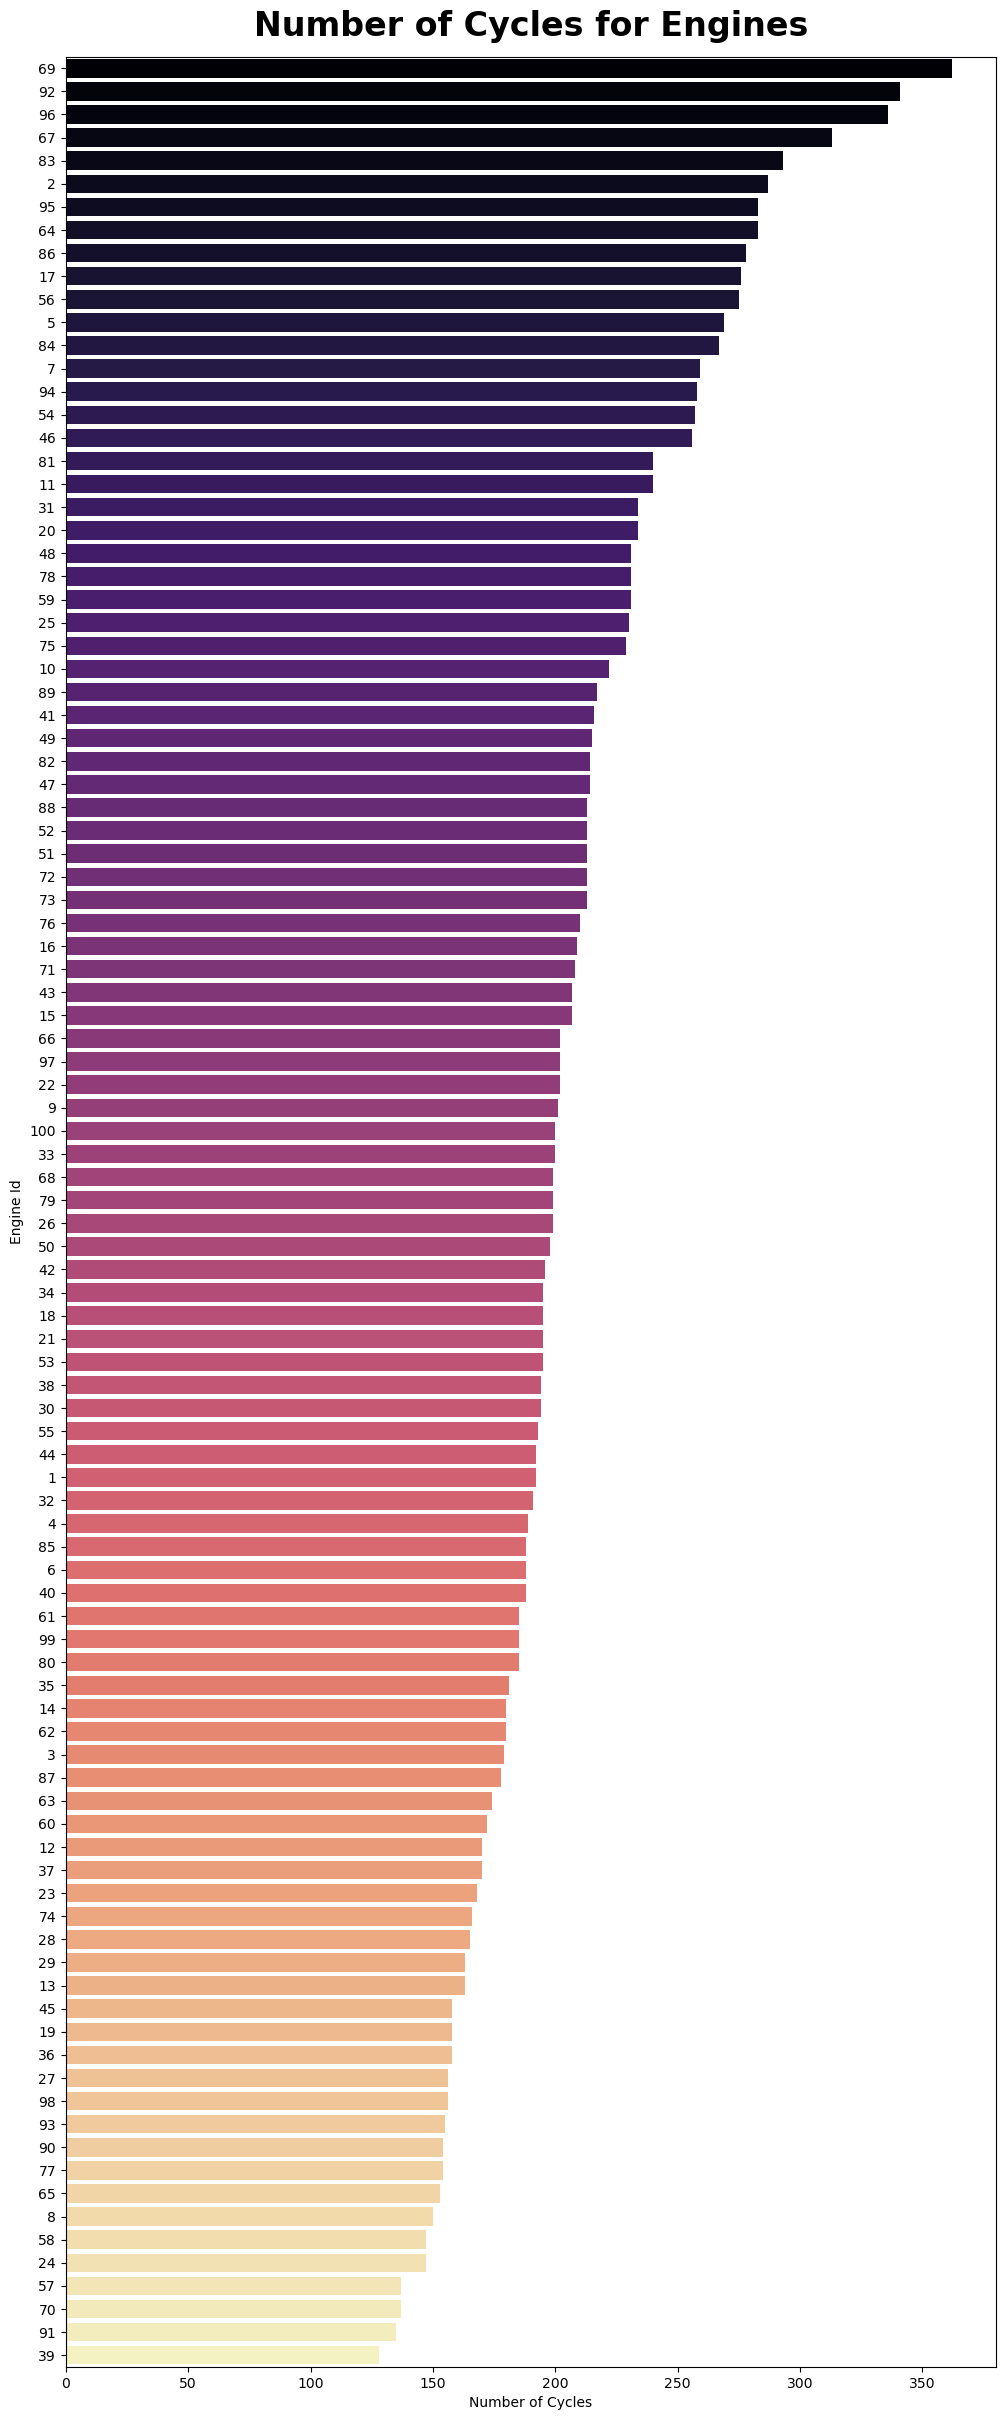

In [10]:
cnt_train = train[["unit_ID", "cycles"]].groupby("unit_ID").max().sort_values(by="cycles", ascending=False)
cnt_ind = [str(i) for i in cnt_train.index.to_list()]
cnt_val = list(cnt_train.cycles.values)

plt.figure(figsize=(12, 30))
sns.barplot(x=list(cnt_val), y=list(cnt_ind), palette='magma')
plt.xlabel('Number of Cycles')
plt.ylabel('Engine Id')
plt.title('Number of Cycles for Engines', fontweight='bold', fontsize=24, pad=15)

plt.show()

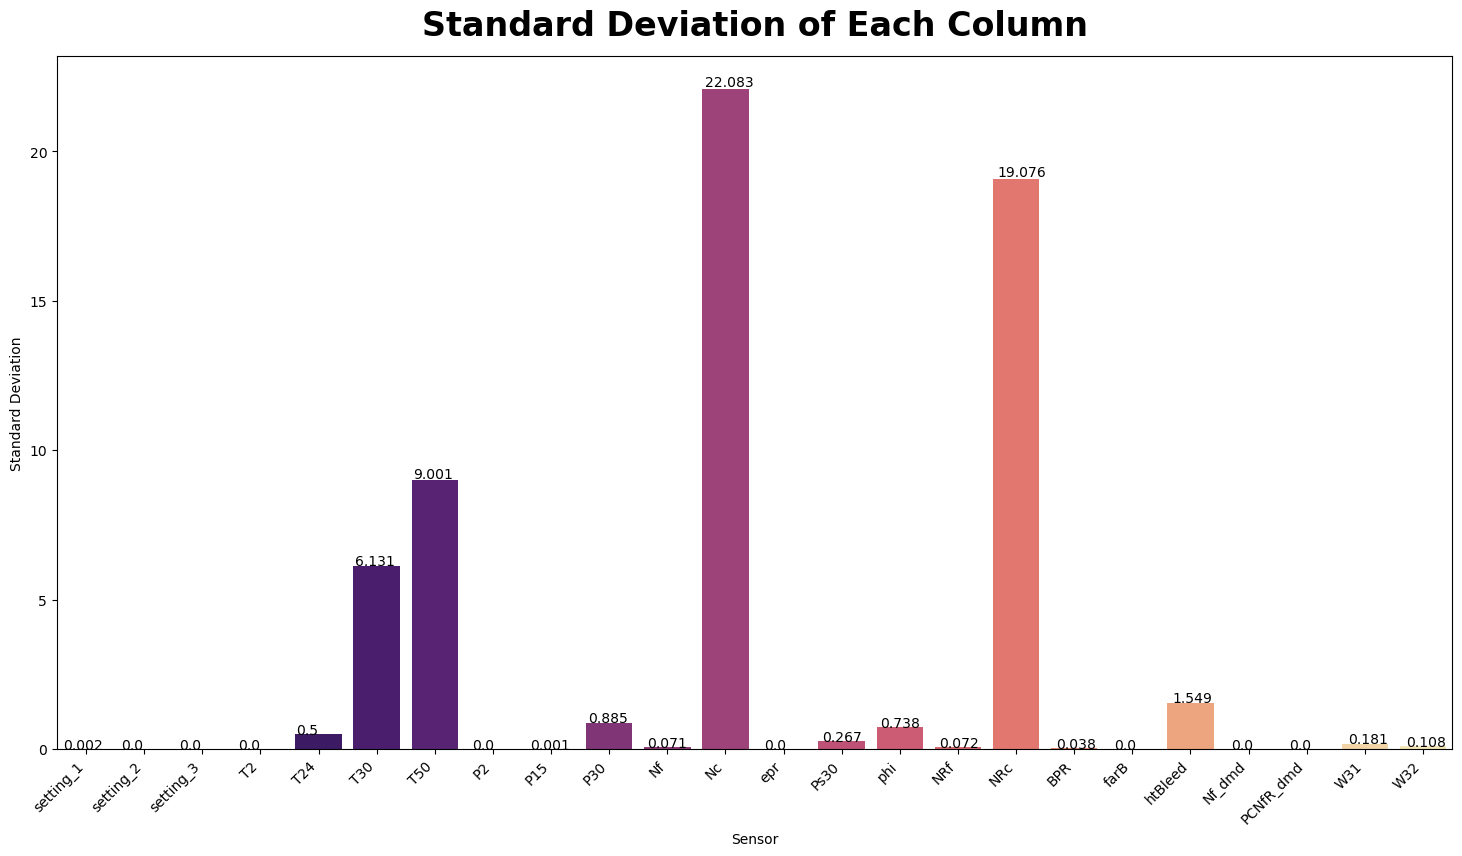

In [11]:
plt.figure(figsize=(18, 9))
subset_stats = data_train.agg(['mean', 'std']).T[2:]
ax = sns.barplot(x=subset_stats.index, y="std", data=subset_stats, palette='magma')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
ax.set_xlabel("Sensor")
ax.set_ylabel("Standard Deviation")
ax.set_title("Standard Deviation of Each Column", fontweight='bold', fontsize=24, pad=15)

for p in ax.patches:
    ax.annotate(str(round(p.get_height(),3)), (p.get_x() * 1.005, p.get_height() * 1.005))

plt.show()

NC with a standard deviation of 22.083, suggests that the values of this variable are quite spread out from the mean.

In [12]:
train.drop(columns=['Nf_dmd','PCNfR_dmd','P2','T2','setting_3','farB','epr'],inplace=True)

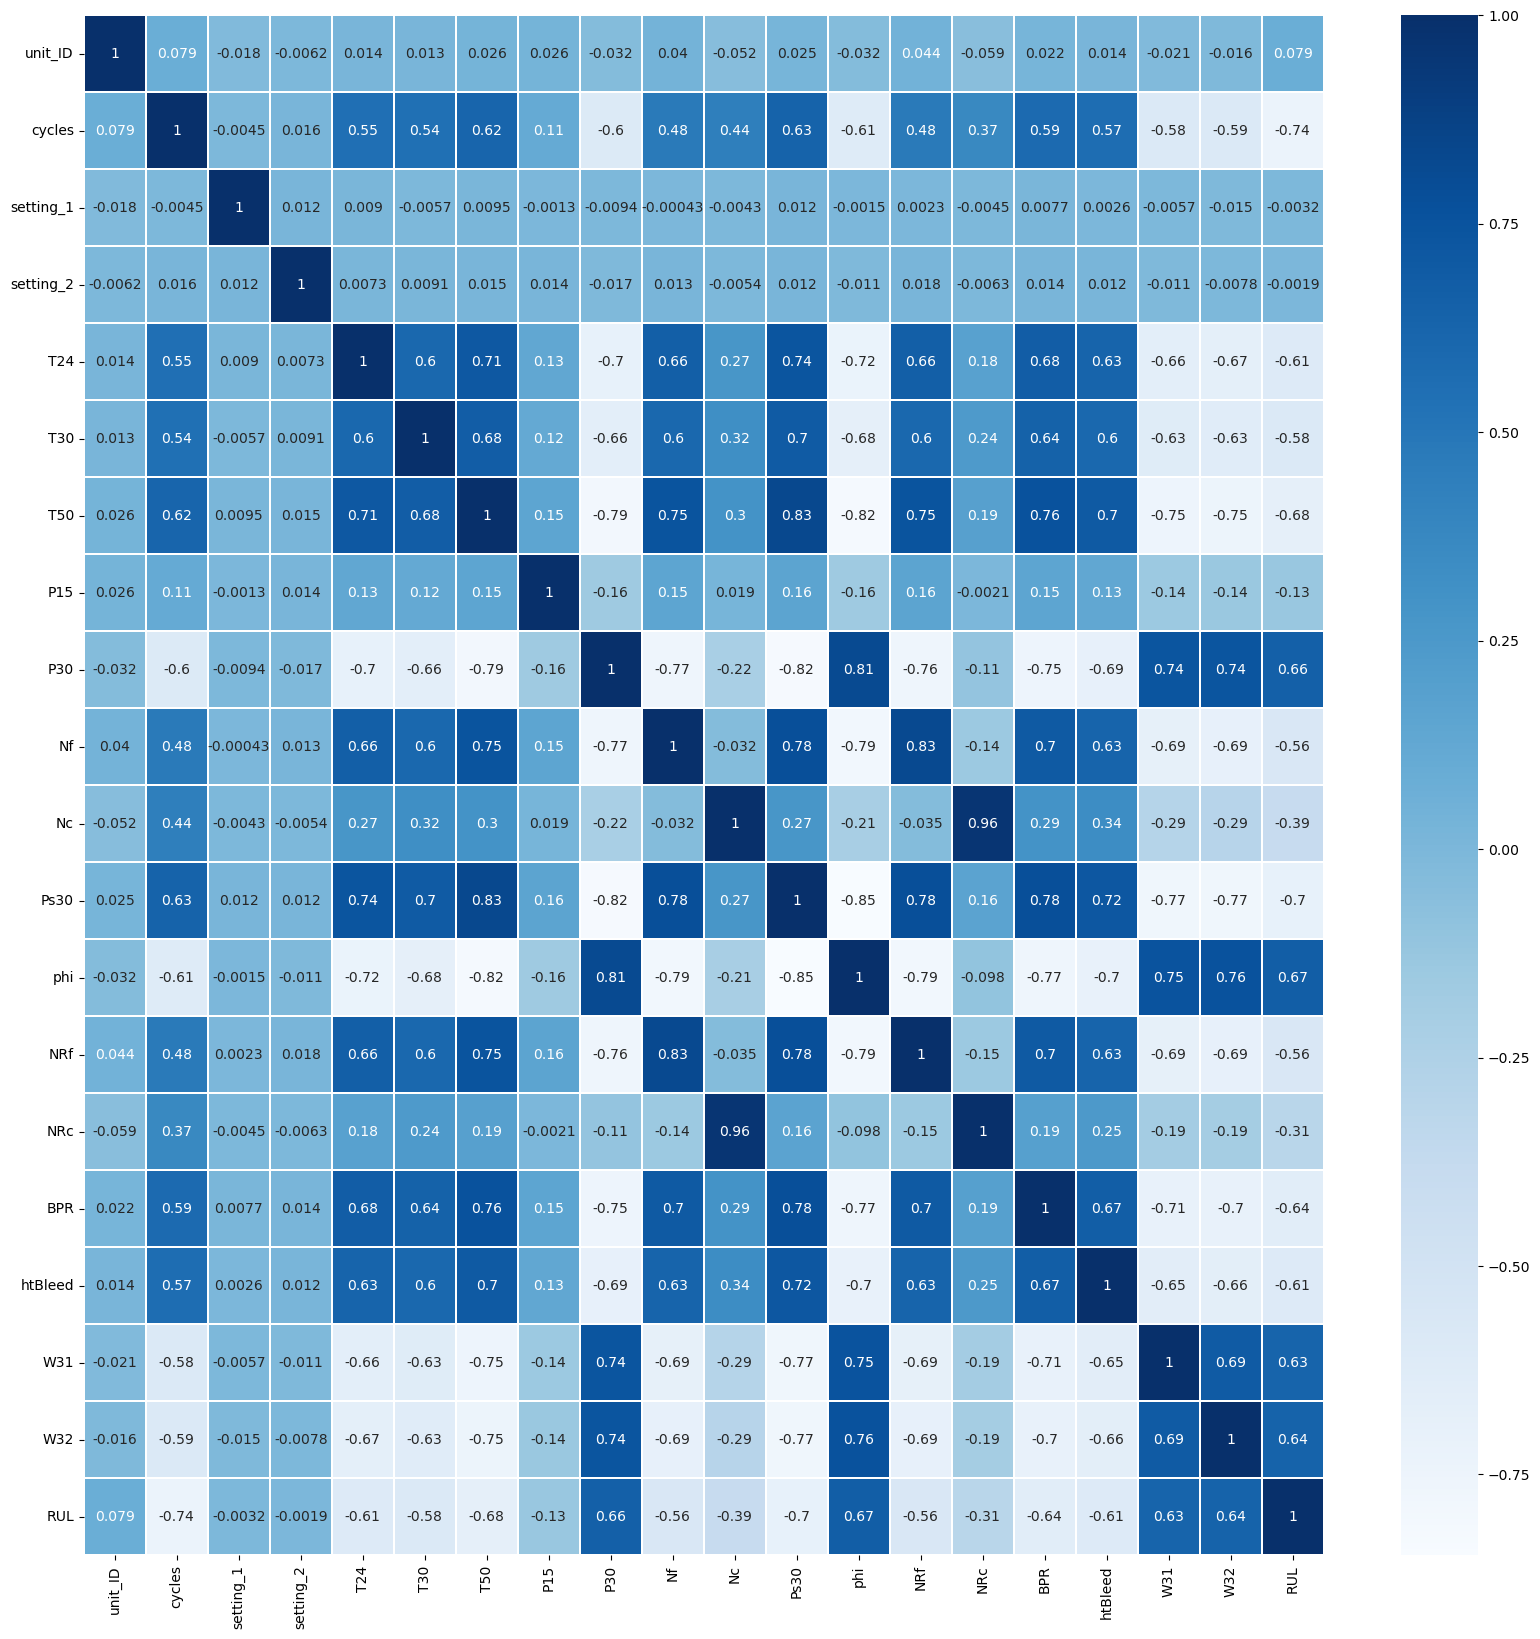

In [13]:
sns.heatmap(train.corr(),annot=True,cmap='Blues',linewidths=0.2)
fig=plt.gcf()
fig.set_size_inches(20,20)
plt.show()

Takes datalength and earlyrul as input and creates target RUL.

This function takes in two arguments, data_length and early_rul. It returns an array that represents the remaining useful life (RUL) for each cycle in the input data. If the early_rul_duration is less than or equal to 0, then the target variable is a reversed range of data_length-1 to 0.

In [14]:
def process_targets(data_length, early_rul = None):
    if early_rul == None:
        return np.arange(data_length-1, -1, -1)
    else:
        early_rul_duration = data_length - early_rul
        if early_rul_duration <= 0:
            return np.arange(data_length-1, -1, -1)
        else:
            return np.append(early_rul*np.ones(shape = (early_rul_duration,)), np.arange(early_rul-1, -1, -1))

This function takes in input data and target data and processes them with a specified window length and shift size. The output_data is a numpy array with shape (num_batches, window_length, num_features). If target_data is not None, the function also outputs output_targets, a numpy array with shape (num_batches,) containing the target values for each batch.

In [15]:
def process_input_data_with_targets(input_data, target_data = None, window_length = 1, shift = 1):
    num_batches = int(np.floor((len(input_data) - window_length)/shift)) + 1
    num_features = input_data.shape[1]
    output_data = np.repeat(np.nan, repeats = num_batches * window_length * num_features).reshape(num_batches, window_length,
                                                                                                  num_features)
    if target_data is None:
        for batch in range(num_batches):
            output_data[batch,:,:] = input_data[(0+shift*batch):(0+shift*batch+window_length),:]
        return output_data
    else:
        output_targets = np.repeat(np.nan, repeats = num_batches)
        for batch in range(num_batches):
            output_data[batch,:,:] = input_data[(0+shift*batch):(0+shift*batch+window_length),:]
            output_targets[batch] = target_data[(shift*batch + (window_length-1))]
        return output_data, output_targets

This function processes the test data for a single engine in preparation for making predictions using a trained model. It takes in the test data for a single engine (test_data_for_an_engine), the window_length and shift parameters that were used in preparing the training data, and the number of test windows (num_test_windows) that should be processed.

In [16]:
def process_test_data(test_data_for_an_engine, window_length, shift, num_test_windows = 1):
  
    max_num_test_batches = int(np.floor((len(test_data_for_an_engine) - window_length)/shift)) + 1
    if max_num_test_batches < num_test_windows:
        required_len = (max_num_test_batches -1)* shift + window_length
        batched_test_data_for_an_engine = process_input_data_with_targets(test_data_for_an_engine[-required_len:, :],
                                                                          target_data = None,
                                                                          window_length= window_length, shift = shift)
        return batched_test_data_for_an_engine, max_num_test_batches
    else:
        required_len = (num_test_windows - 1) * shift + window_length
        batched_test_data_for_an_engine = process_input_data_with_targets(test_data_for_an_engine[-required_len:, :],
                                                                          target_data = None,
                                                                          window_length= window_length, shift = shift)
        return batched_test_data_for_an_engine, num_test_windows

The default option is to take only the last window of test data for each engine, which amounts to one window. However, if you set the number to a different value, that many windows from the last will be taken, and the final output will be the average of all the windows.

In [17]:
test_data = pd.read_csv("/kaggle/input/nasa-cmaps/CMaps/test_FD001.txt", sep = "\s+", header = None,names=columns_train )
true_rul = pd.read_csv("/kaggle/input/nasa-cmaps/CMaps/RUL_FD001.txt", sep = '\s+', header = None)

window_length = 30
shift = 1
early_rul = 125           
processed_train_data = []
processed_train_targets = []
num_test_windows = 5     
processed_test_data = []
num_test_windows_list = []

columns_to_be_dropped =['unit_ID','setting_1','setting_2','setting_3', 'T2', 'P2','P15', 'epr',
                 'farB', 'Nf_dmd', 'PCNfR_dmd']

train_data_first_column = data_train ["unit_ID"]
test_data_first_column = test_data["unit_ID"]

Scale data for all engines

In [18]:
scaler = StandardScaler()
train_data = scaler.fit_transform(data_train.drop(columns = columns_to_be_dropped))
test_data = scaler.transform(test_data.drop(columns = columns_to_be_dropped))

train_data = pd.DataFrame(data = np.c_[train_data_first_column, train_data])
test_data = pd.DataFrame(data = np.c_[test_data_first_column, test_data])

num_train_machines = len(train_data[0].unique())
num_test_machines = len(test_data[0].unique())

It is important to process the training and test data separately since the number of engines in each set may differ.
Since we scale the entire dataset, we do not need to be concerned about the differing number of engines between the training and test sets.

**Training data process:**

In [19]:
for i in np.arange(1, num_train_machines + 1):
    temp_train_data = train_data[train_data[0] == i].drop(columns = [0]).values
    
    # Determine whether it is possible to extract training data with the specified window length.
    if (len(temp_train_data) < window_length):
        print("Train engine {} doesn't have enough data for window_length of {}".format(i, window_length))
        raise AssertionError("Window length is larger than number of data points for some engines. "
                             "Try decreasing window length.")
        
    temp_train_targets = process_targets(data_length = temp_train_data.shape[0], early_rul = early_rul)
    data_for_a_machine, targets_for_a_machine = process_input_data_with_targets(temp_train_data, temp_train_targets, 
                                                                                window_length= window_length, shift = shift)
    
    processed_train_data.append(data_for_a_machine)
    processed_train_targets.append(targets_for_a_machine)

processed_train_data = np.concatenate(processed_train_data)
processed_train_targets = np.concatenate(processed_train_targets)

**Test data process:**

In [20]:
for i in np.arange(1, num_test_machines + 1):
    temp_test_data = test_data[test_data[0] == i].drop(columns = [0]).values
    
    # Determine whether it is possible to extract test data with the specified window length.
    if (len(temp_test_data) < window_length):
        print("Test engine {} doesn't have enough data for window_length of {}".format(i, window_length))
        raise AssertionError("Window length is larger than number of data points for some engines. "
                             "Try decreasing window length.")
    
    # Prepare test data
    test_data_for_an_engine, num_windows = process_test_data(temp_test_data, window_length=window_length, shift = shift,
                                                             num_test_windows = num_test_windows)
    
    processed_test_data.append(test_data_for_an_engine)
    num_test_windows_list.append(num_windows)

processed_test_data = np.concatenate(processed_test_data)
true_rul = true_rul[0].values

In [21]:
print("Processed trianing data shape: ", processed_train_data.shape)
print("Processed training ruls shape: ", processed_train_targets.shape)
print("Processed test data shape: ", processed_test_data.shape)
print("True RUL shape: ", true_rul.shape)

Processed trianing data shape:  (17731, 30, 15)
Processed training ruls shape:  (17731,)
Processed test data shape:  (497, 30, 15)
True RUL shape:  (100,)


The shape of processed_train_data is (17731, 30, 14), which means we have 17731 engines, each with 30 time steps and 14 sensor readings at each time step.
The shape of processed_train_targets is (17731,), which means we have the corresponding target RUL values for the 17731 training samples.
The shape of processed_test_data is (497, 30, 14), which means we have 497 test or engines, each with 30 time steps and 14 sensor readings at each time step.
The shape of true_rul is (100,), which means we have the true RUL values for 100 test engines.

In [22]:
X_train, X_val, y_train, y_val = train_test_split(processed_train_data, processed_train_targets, test_size = 0.2, random_state = 83)

print("Processed train data shape: ", X_train.shape)
print("Processed validation data shape: ", X_val.shape)
print("Processed train targets shape: ", y_train.shape)
print("Processed validation targets shape: ", y_val.shape)

Processed train data shape:  (14184, 30, 15)
Processed validation data shape:  (3547, 30, 15)
Processed train targets shape:  (14184,)
Processed validation targets shape:  (3547,)


# **LSTM**

LSTM stands for long short-term memory networks, used in the field of Deep Learning. It is a variety of recurrent neural networks (RNNs) that are capable of learning long-term dependencies, especially in sequence prediction problems.

This function creates a compiled model using the Keras Sequential API with the following architecture:
LSTM layer with 128 units, input shape of (window_length, 14), returns sequences and uses the hyperbolic tangent activation function.
LSTM layer with 64 units, returns sequences and uses the hyperbolic tangent activation function.
LSTM layer with 32 units, uses the hyperbolic tangent activation function.
Dense layer with 96 units and Rectified Linear Unit (ReLU) activation function. Dense layer with 128 units and ReLU activation function. Dense layer with 1 unit. The loss function used is mean squared error, and the optimizer used is with a learning rate of 0.001.

In [23]:
def create_compiled_model():
    model = Sequential([
        layers.LSTM(128, input_shape = (window_length, 15), return_sequences=True, activation = "tanh"),
        layers.LSTM(64, activation = "tanh", return_sequences = True),
        layers.LSTM(32, activation = "tanh"),
        layers.Dense(96, activation = "relu"),
        layers.Dense(128, activation = "relu"),
        layers.Dense(1)
    ])
    model.compile(loss = "mse", optimizer = tf.keras.optimizers.Adam(learning_rate=0.001))
    return model

Scheduler is a function that adjusts the learning rate during the training process, with the goal of improving the model's performance.
By adjusting the learning rate based on the epoch number, the scheduler can help the model converge more quickly and accurately.

In [24]:
def scheduler(epoch):
    if epoch < 5:
        return 0.001
    else:
        return 0.0001
callback = tf.keras.callbacks.LearningRateScheduler(scheduler, verbose = 0)
model = create_compiled_model()
history = model.fit(X_train, y_train, epochs = 10,
                    validation_data = (X_val, y_val),
                    callbacks = callback,
                    batch_size = 128, verbose = 2)

Epoch 1/10
111/111 - 13s - loss: 2971.2021 - val_loss: 741.6407 - lr: 0.0010 - 13s/epoch - 120ms/step
Epoch 2/10
111/111 - 1s - loss: 431.6476 - val_loss: 230.9637 - lr: 0.0010 - 1s/epoch - 10ms/step
Epoch 3/10
111/111 - 1s - loss: 190.5088 - val_loss: 168.5802 - lr: 0.0010 - 1s/epoch - 9ms/step
Epoch 4/10
111/111 - 1s - loss: 148.8829 - val_loss: 131.5126 - lr: 0.0010 - 1s/epoch - 9ms/step
Epoch 5/10
111/111 - 1s - loss: 127.0070 - val_loss: 134.4010 - lr: 0.0010 - 1s/epoch - 11ms/step
Epoch 6/10
111/111 - 1s - loss: 100.2051 - val_loss: 98.4652 - lr: 1.0000e-04 - 1s/epoch - 10ms/step
Epoch 7/10
111/111 - 1s - loss: 93.7708 - val_loss: 94.7228 - lr: 1.0000e-04 - 1s/epoch - 10ms/step
Epoch 8/10
111/111 - 1s - loss: 91.2249 - val_loss: 91.6598 - lr: 1.0000e-04 - 1s/epoch - 9ms/step
Epoch 9/10
111/111 - 1s - loss: 88.3529 - val_loss: 89.2223 - lr: 1.0000e-04 - 1s/epoch - 10ms/step
Epoch 10/10
111/111 - 1s - loss: 85.6597 - val_loss: 87.6054 - lr: 1.0000e-04 - 1s/epoch - 9ms/step


Measure the difference between predicted and actual values.
RMSE = sqrt(1/n * Σ(actual_i - predicted_i)^2)

In [25]:
rul_pred = model.predict(processed_test_data).reshape(-1)
preds_for_each_engine = np.split(rul_pred, np.cumsum(num_test_windows_list)[:-1])
mean_pred_for_each_engine = [np.average(ruls_for_each_engine, weights = np.repeat(1/num_windows, num_windows)) 
                             for ruls_for_each_engine, num_windows in zip(preds_for_each_engine, num_test_windows_list)]
RMSE = np.sqrt(mean_squared_error(true_rul, mean_pred_for_each_engine))
print("RMSE: ", RMSE)

16/16 [==============================] - 1s 4ms/step
RMSE:  14.975514135891538


Save this RMSE to use as a breaking point in the Active Learning loop

In [26]:
original_RMSE = RMSE

To compute the RMSE, we consider only the last example of each engine.

In [27]:
indices_of_last_examples = np.cumsum(num_test_windows_list) - 1
preds_for_last_example = np.concatenate(preds_for_each_engine)[indices_of_last_examples]

RMSE_new = np.sqrt(mean_squared_error(true_rul, preds_for_last_example))
print("RMSE (Taking only last examples): ", RMSE_new)

RMSE (Taking only last examples):  15.418485301305237


A value of 15.30 indicates that the average deviation of the predictions from the actual values is around 15.30

rul_true and rul_pred should be 1D numpy arrays

It is a measure of the difference between the actual and predicted RUL values normalized by the standard deviation of the RUL.
A higher S-score indicates a better prediction performance.
In general, an S-score of 458.1 indicates a good performance of the prediction model.

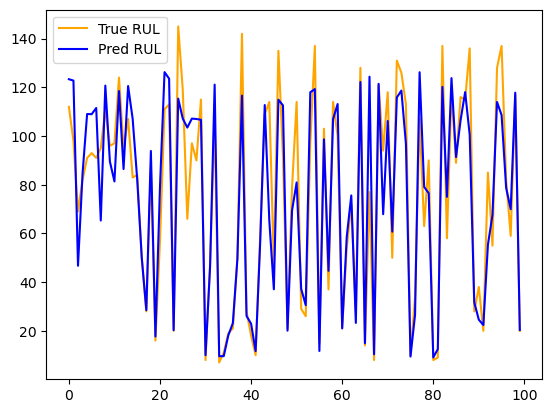

In [28]:
plt.plot(true_rul, label = "True RUL", color = "orange")
plt.plot(preds_for_last_example, label = "Pred RUL", color = "blue")
plt.legend()
plt.show()

# Active Learning algorithms

In this section, we will implement and evaluate three active learning strategies to reduce the amount of labeled data required for training our LSTM model on RUL prediction. The objective is to achieve comparable performance to using the entire dataset while significantly reducing data acquisition costs.

### Overview of the Methods
We will implement and compare the following active learning approaches:

1. Custom Error-Based Uncertainty Method
2. Monte Carlo Dropout Uncertainty Estimation
3. Ensemble-Based Uncertainty Estimation

In [29]:
# Setup initial data and query number for the Active Learning algorithms (percentage of entire dataset)
data_parts = 20 # number of parts to divide the data, for the active learning loop
total_runs = 20  # This variable is to run X amount of times each active learning loop, to have an average value, due to the random nature of the models

## Custom Uncertainty sampling function

The first approach involves a straightforward way to quantify uncertainty using prediction errors:

In this method, we calculate the squared error between the model's predictions and the ground truth values. The higher the squared error, the higher the uncertainty associated with that prediction.
Implementation Strategy:
1. Train the LSTM model on an initial subset of the data.
2. For each new data point, predict the RUL using the trained model.
3. Calculate the squared error for each prediction and prioritize data points with the highest errors for labeling and retraining.

In [30]:
def uncertainty_sampling(pool_preds, y_pool, n_queries):
    # Compute the squared error based uncertainty (uncertainty proxy)
    error_uncertainty = (pool_preds - y_pool) ** 2
    
    # Select the top `n_queries` most uncertain samples
    # When the y_pool does not have sufficient data for the desired nr of queries, reduce to remaining number of queries
    if y_pool.shape[0] < n_queries:
        n_queries = y_pool.shape[0]
        query_idx = np.argsort(error_uncertainty)[-n_queries:]  # Get indices of top uncertainties
    else:
        query_idx = np.argsort(error_uncertainty)[-n_queries:]  # Get indices of top uncertainties
    
    return query_idx

In [31]:
def AL_custom_uncertainty_loop(data_parts, processed_train_data, processed_train_targets, processed_test_data):
    # Split the data into train and test data
    X_train, X_val, y_train, y_val = train_test_split(processed_train_data, processed_train_targets, test_size = 0.2, random_state = 83)
    
    # Divide the train data into equal parts
    X_train_divided = np.array_split(X_train, data_parts)
    y_train_divided = np.array_split(y_train, data_parts)
    
    # Initialize RMSE array and percentage of data used for plotting in the end
    rmse_list = []
        
    # Active learning loop
    for iteration in range(data_parts):
        print(f"Iteration {iteration+1}/{data_parts}")
        print(f"Training data size: {X_train_divided[iteration].shape[0]}")
        
        # Train the model on the current labeled data
        model_AL.fit(X_train_divided[iteration], y_train_divided[iteration], epochs = 10, validation_data = (X_val, y_val), callbacks = callback, batch_size = 128, verbose = 0)
    
        # Calculate the RMSE of the current model iteration
        rul_pred = model_AL.predict(processed_test_data).reshape(-1)
        preds_for_each_engine = np.split(rul_pred, np.cumsum(num_test_windows_list)[:-1])
        mean_pred_for_each_engine = [np.average(ruls_for_each_engine, weights = np.repeat(1/num_windows, num_windows)) 
                                     for ruls_for_each_engine, num_windows in zip(preds_for_each_engine, num_test_windows_list)]
        RMSE = np.sqrt(mean_squared_error(true_rul, mean_pred_for_each_engine))
    
        # Save the current RMSE to the RMSE array for saving the values
        rmse_list.append(RMSE)
        print("RMSE: ", RMSE)
    
        # Calculate predictions for the uncertainty calculation
        if iteration < 19:
            # The remaining parts are joined into an X and y pool
            X_pool = np.concatenate(X_train_divided[iteration + 1:], axis=0)
            y_pool = np.concatenate(y_train_divided[iteration + 1:], axis=0)

            # The number of queries is equal to the size of the next part
            n_queries = X_train_divided[iteration + 1].shape[0]
            
            # Predict the X_pool values
            preds = model_AL.predict(X_pool).reshape(-1)
        
            # Query the most uncertain samples from the pool
            query_idx = uncertainty_sampling(preds, y_pool, n_queries)
        
    return rmse_list

In [32]:
# Initialize array to store all the rmse arrays
total_custom_uncertainty_rmse = []

# Execute active learning runs
for _ in range(total_runs):
    # Create the model again, to add to the active learner
    model_AL = create_compiled_model()

    # Run the Active learning loop
    custom_uncertainty_rmse = AL_custom_uncertainty_loop(data_parts,  
                           processed_train_data, 
                           processed_train_targets, 
                           processed_test_data)

    # Stack the current run rmse to the total rmse matrix
    total_custom_uncertainty_rmse.append(custom_uncertainty_rmse)

# Turn the rmse matrix into a numpy array for processing
total_custom_uncertainty_rmse = np.array(total_custom_uncertainty_rmse)
np.savetxt("RMSE_Custom_Uncertainty_method.csv", total_custom_uncertainty_rmse, delimiter=",", fmt="%.2f", header="RMSE", comments='')

Iteration 1/20
Training data size: 710
16/16 [==============================] - 1s 4ms/step
RMSE:  65.11897469967367
422/422 [==============================] - 2s 4ms/step
Iteration 2/20
Training data size: 710
16/16 [==============================] - 0s 4ms/step
RMSE:  19.9591302553951
399/399 [==============================] - 1s 4ms/step
Iteration 3/20
Training data size: 710
16/16 [==============================] - 0s 4ms/step
RMSE:  15.632358487909913
377/377 [==============================] - 1s 4ms/step
Iteration 4/20
Training data size: 710
16/16 [==============================] - 0s 4ms/step
RMSE:  15.983141528203209
355/355 [==============================] - 1s 4ms/step
Iteration 5/20
Training data size: 709
16/16 [==============================] - 0s 4ms/step
RMSE:  15.23732574674097
333/333 [==============================] - 1s 4ms/step
Iteration 6/20
Training data size: 709
16/16 [==============================] - 0s 4ms/step
RMSE:  15.076151480094769
311/311 [============

## Monte Carlo Method

The second approach leverages Monte Carlo (MC) Dropout for estimating model uncertainty:

The idea behind Monte Carlo Dropout is to keep dropout layers active during inference. By running multiple forward passes with dropout enabled, we can obtain a distribution of predictions, which can then be used to estimate uncertainty. The standard deviation of these predictions is a measure of uncertainty.
Implementation Strategy:
1. Add dropout layers to the LSTM model architecture.
2. During inference, perform multiple forward passes, 100 in this example, with dropout enabled.
3. Calculate the mean and standard deviation of the predictions to determine uncertainty.

In [33]:
# Function to make predictions with dropout
def MC_uncertainty(model, X_pool, n_queries, n_iter=100):
    predictions = np.array([model(X_pool, training=True).numpy() for _ in range(n_iter)])
    prediction_std = predictions.std(axis=0).flatten()

    # Select the top `n_queries` most uncertain samples
    # When the y_pool does not have sufficient data for the desired nr of queries, reduce to remaining number of queries
    if X_pool.shape[0] < n_queries:
        n_queries = X_pool.shape[0]
        query_idx = np.argsort(prediction_std)[-n_queries:]  # Get indices of top uncertainties
    else:
        query_idx = np.argsort(prediction_std)[-n_queries:]  # Get indices of top uncertainties
    
    return query_idx

In [34]:
def create_model_MC():
    model = Sequential([
        layers.LSTM(128, input_shape = (window_length, 15), return_sequences=True, activation = "tanh"),
        layers.Dropout(0.3),
        layers.LSTM(64, activation = "tanh", return_sequences = True),
        layers.Dropout(0.3),
        layers.LSTM(32, activation = "tanh"),
        layers.Dropout(0.3),
        layers.Dense(96, activation = "relu"),
        layers.Dense(128, activation = "relu"),
        layers.Dense(1)
    ])
    model.compile(loss = "mse", optimizer = tf.keras.optimizers.Adam(learning_rate=0.001))
    return model

In [35]:
def AL_MC_dropout_loop(data_parts, processed_train_data, processed_train_targets, processed_test_data):
    # Split the data into train and test data
    X_train, X_val, y_train, y_val = train_test_split(processed_train_data, processed_train_targets, test_size = 0.2, random_state = 83)
    
    # Divide the train data into equal parts
    X_train_divided = np.array_split(X_train, data_parts)
    y_train_divided = np.array_split(y_train, data_parts)
    
    # Initialize RMSE array and percentage of data used for plotting in the end
    rmse_list = []
        
    # Active learning loop
    for iteration in range(data_parts):
        print(f"Iteration {iteration+1}/{data_parts}")
        print(f"Training data size: {X_train_divided[iteration].shape[0]}")
        
        # Train the model on the current labeled data
        MC_model.fit(X_train_divided[iteration], y_train_divided[iteration], epochs = 10, validation_data = (X_val, y_val), callbacks = callback, batch_size = 128, verbose = 0)
    
        # Calculate the RMSE of the current model iteration
        rul_pred = MC_model.predict(processed_test_data).reshape(-1)
        preds_for_each_engine = np.split(rul_pred, np.cumsum(num_test_windows_list)[:-1])
        mean_pred_for_each_engine = [np.average(ruls_for_each_engine, weights = np.repeat(1/num_windows, num_windows)) 
                                     for ruls_for_each_engine, num_windows in zip(preds_for_each_engine, num_test_windows_list)]
        RMSE = np.sqrt(mean_squared_error(true_rul, mean_pred_for_each_engine))
    
        # Save the current RMSE to the RMSE array for saving the values
        rmse_list.append(RMSE)
        print("RMSE: ", RMSE)
    
        # Calculate predictions for the uncertainty calculation
        if iteration < 19:
            # The remaining parts are joined into an X and y pool
            X_pool = np.concatenate(X_train_divided[iteration + 1:], axis=0)
            y_pool = np.concatenate(y_train_divided[iteration + 1:], axis=0)

            # The number of queries is equal to the size of the next part
            n_queries = X_train_divided[iteration + 1].shape[0]
        
            # Query the most uncertain samples from the pool
            query_idx = MC_uncertainty(MC_model, X_pool, n_queries, n_iter=100)
        
    return rmse_list

In [36]:
# Initialize array to store all the rmse arrays
total_MC_dropout_rmse = []

# Execute active learning runs
for _ in range(total_runs):
    # Create the model again, to add to the active learner
    MC_model = create_model_MC()

    # Run the Active learning loop
    custom_uncertainty_rmse = AL_MC_dropout_loop(data_parts,  
                           processed_train_data, 
                           processed_train_targets, 
                           processed_test_data)

    # Stack the current run rmse to the total rmse matrix
    total_MC_dropout_rmse.append(custom_uncertainty_rmse)

# Turn the rmse matrix into a numpy array for processing
total_MC_dropout_rmse = np.array(total_MC_dropout_rmse)
np.savetxt("RMSE_Monte_Carlo_method.csv", total_MC_dropout_rmse, delimiter=",", fmt="%.2f", header="RMSE", comments='')

Iteration 1/20
Training data size: 710
16/16 [==============================] - 1s 4ms/step
RMSE:  58.459963056485535
Iteration 2/20
Training data size: 710
16/16 [==============================] - 0s 4ms/step
RMSE:  19.750643249627885
Iteration 3/20
Training data size: 710
16/16 [==============================] - 0s 4ms/step
RMSE:  16.644563086078605
Iteration 4/20
Training data size: 710
16/16 [==============================] - 0s 4ms/step
RMSE:  17.322286579197456
Iteration 5/20
Training data size: 709
16/16 [==============================] - 0s 4ms/step
RMSE:  16.847594373873303
Iteration 6/20
Training data size: 709
16/16 [==============================] - 0s 4ms/step
RMSE:  16.396168810703486
Iteration 7/20
Training data size: 709
16/16 [==============================] - 0s 4ms/step
RMSE:  15.523363638998674
Iteration 8/20
Training data size: 709
16/16 [==============================] - 0s 4ms/step
RMSE:  14.929025088452693
Iteration 9/20
Training data size: 709
16/16 [==========

## Ensemble Method

The third approach involves using an ensemble of models to estimate uncertainty:

This method trains multiple models (with different initializations) on the same dataset. During inference, each model makes a prediction, and the variance of these predictions is used as a measure of uncertainty. The intuition is that if the models disagree significantly, the prediction is more uncertain.
Implementation Strategy:
1. Train multiple LSTM models , 5 models in this example, on the same subset of data but with different random seeds.
2. During inference, obtain predictions from each model.
3. Calculate the mean and standard deviation of the ensemble predictions to estimate uncertainty.

In [37]:
# Function to make predictions with dropout
def ensemble_uncertainty(model_ensemble, X_pool, n_queries):
    predictions = np.array([model.predict(X_pool) for model in model_ensemble])
    prediction_std = predictions.std(axis=0).flatten()

    # Select the top `n_queries` most uncertain samples
    # When the y_pool does not have sufficient data for the desired nr of queries, reduce to remaining number of queries
    if X_pool.shape[0] < n_queries:
        n_queries = X_pool.shape[0]
        query_idx = np.argsort(prediction_std)[-n_queries:]  # Get indices of top uncertainties
    else:
        query_idx = np.argsort(prediction_std)[-n_queries:]  # Get indices of top uncertainties
    
    return query_idx

In [38]:
def AL_ensemble_loop(data_parts, processed_train_data, processed_train_targets, processed_test_data):
    # Split the data into train and test data
    X_train, X_val, y_train, y_val = train_test_split(processed_train_data, processed_train_targets, test_size = 0.2, random_state = 83)
    
    # Divide the train data into equal parts
    X_train_divided = np.array_split(X_train, data_parts)
    y_train_divided = np.array_split(y_train, data_parts)
    
    # Initialize RMSE array and percentage of data used for plotting in the end
    rmse_list = []
        
    # Active learning loop
    for iteration in range(data_parts):
        print(f"Iteration {iteration+1}/{data_parts}")
        print(f"Training data size: {X_train_divided[iteration].shape[0]}")
        
        # Train the model on the current labeled data
        main_model.fit(X_train_divided[iteration], y_train_divided[iteration], epochs = 10, validation_data = (X_val, y_val), callbacks = callback, batch_size = 128, verbose = 0)
    
        # Train the ensemble of models on the current labeled data
        for model in model_ensemble:
            model.fit(X_train_divided[iteration], y_train_divided[iteration], epochs = 10, validation_data = (X_val, y_val), callbacks = callback, batch_size = 128, verbose = 0)
        
        # Calculate the RMSE of the current model iteration
        rul_pred = main_model.predict(processed_test_data).reshape(-1)
        preds_for_each_engine = np.split(rul_pred, np.cumsum(num_test_windows_list)[:-1])
        mean_pred_for_each_engine = [np.average(ruls_for_each_engine, weights = np.repeat(1/num_windows, num_windows)) 
                                     for ruls_for_each_engine, num_windows in zip(preds_for_each_engine, num_test_windows_list)]
        RMSE = np.sqrt(mean_squared_error(true_rul, mean_pred_for_each_engine))
    
        # Save the current RMSE to the RMSE array for saving the values
        rmse_list.append(RMSE)
        print("RMSE: ", RMSE)
    
        # Calculate predictions for the uncertainty calculation
        if iteration < 19:
            # The remaining parts are joined into an X and y pool
            X_pool = np.concatenate(X_train_divided[iteration + 1:], axis=0)
            y_pool = np.concatenate(y_train_divided[iteration + 1:], axis=0)

            # The number of queries is equal to the size of the next part
            n_queries = X_train_divided[iteration + 1].shape[0]
        
            # Query the most uncertain samples from the pool
            query_idx = ensemble_uncertainty(model_ensemble, X_pool, n_queries)
        
    return rmse_list

In [39]:
# Initialize array to store all the rmse arrays
total_ensemble_rmse = []

# Execute active learning runs
for _ in range(total_runs):
    # Create the model again, to add to the active learner
    main_model = create_compiled_model()

    # Create an ensemble of models
    ensemble_nr = 5
    
    model_ensemble = []
    for _ in range(ensemble_nr):
        model_ensemble.append(create_compiled_model())

    # Run the Active learning loop
    custom_uncertainty_rmse = AL_ensemble_loop(data_parts,  
                           processed_train_data, 
                           processed_train_targets, 
                           processed_test_data)

    # Stack the current run rmse to the total rmse matrix
    total_ensemble_rmse.append(custom_uncertainty_rmse)

# Turn the rmse matrix into a numpy array for processing
total_ensemble_rmse = np.array(total_ensemble_rmse)
np.savetxt("RMSE_Ensemble_method.csv", total_ensemble_rmse, delimiter=",", fmt="%.2f", header="RMSE", comments='')

Iteration 1/20
Training data size: 710
16/16 [==============================] - 1s 4ms/step
RMSE:  66.7805539865942
422/422 [==============================] - 2s 4ms/step
Iteration 2/20
Training data size: 710
16/16 [==============================] - 0s 4ms/step
RMSE:  36.39166069323194
399/399 [==============================] - 1s 4ms/step
Iteration 3/20
Training data size: 710
16/16 [==============================] - 0s 4ms/step
RMSE:  31.59189761374458
377/377 [==============================] - 1s 4ms/step
Iteration 4/20
Training data size: 710
16/16 [==============================] - 0s 5ms/step
RMSE:  29.170777385766606
355/355 [==============================] - 1s 4ms/step
Iteration 5/20
Training data size: 709
16/16 [==============================] - 0s 4ms/step
RMSE:  21.18166440750307
333/333 [==============================] - 1s 4ms/step
Iteration 6/20
Training data size: 709
16/16 [==============================] - 0s 5ms/step
RMSE:  18.627206236098484
311/311 [=============

# Results of Active Learning strategies

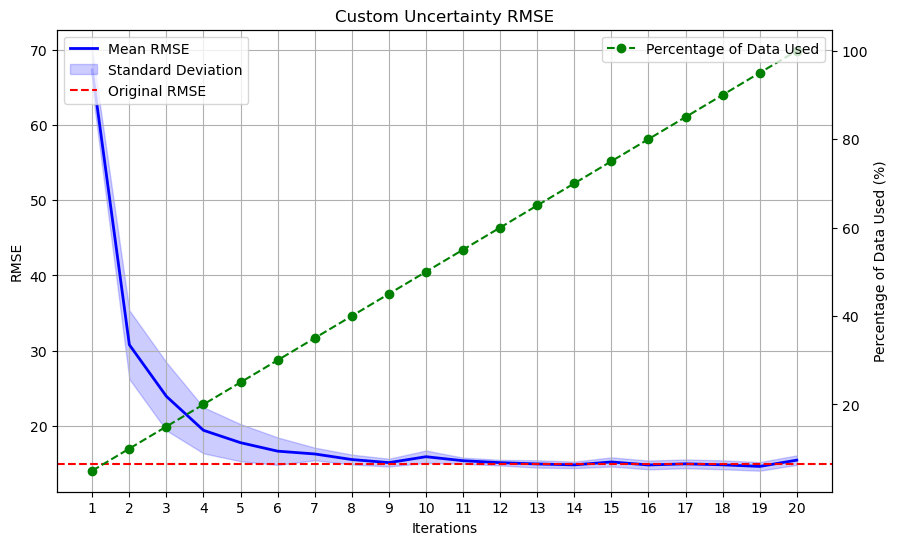

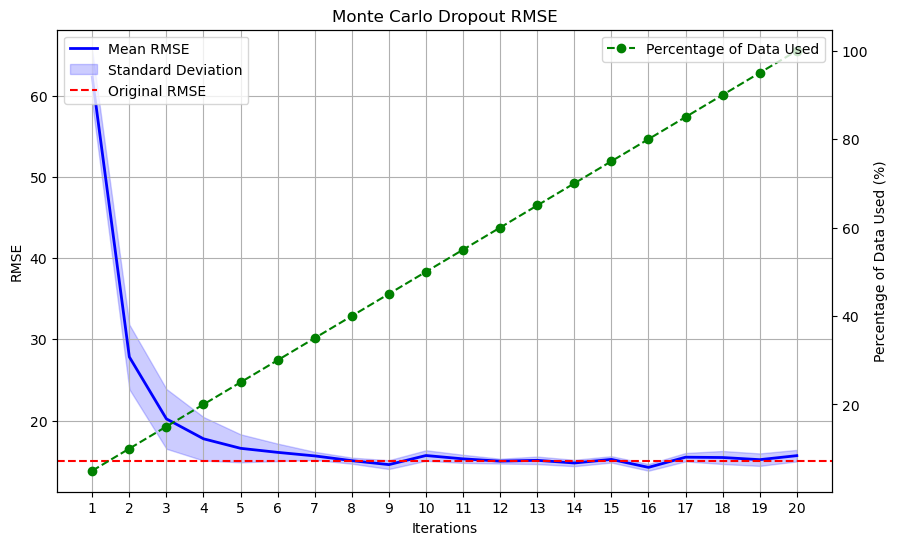

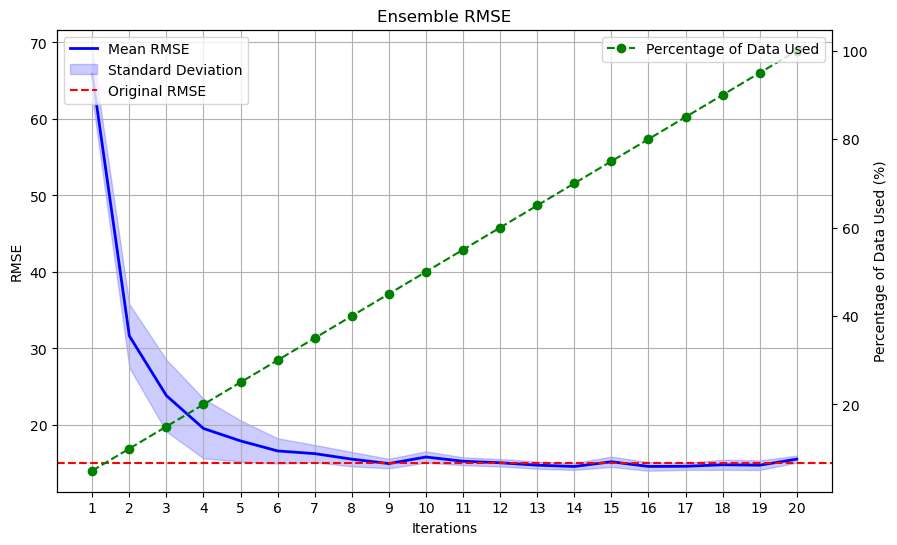

In [40]:
def plot_rmse(mean_values, std_values, data_parts, percentage_list, original_RMSE, title):
    fig, ax1 = plt.subplots(figsize=(10, 6))
    
    x_values = range(1, data_parts + 1)
    
    # Plot RMSE values (Mean RMSE and Standard Deviation)
    ax1.plot(x_values, mean_values, label="Mean RMSE", color="blue", linewidth=2)
    ax1.fill_between(x_values, mean_values - std_values, mean_values + std_values,
                     color="blue", alpha=0.2, label="Standard Deviation")
    ax1.axhline(original_RMSE, color="red", linestyle="--", label="Original RMSE")
    
    ax1.set_xlabel("Iterations")
    ax1.set_ylabel("RMSE")
    ax1.legend(loc="upper left")
    ax1.grid(True)

    # Ensure x-axis increments by 1
    ax1.set_xticks(x_values)
    
    # Create a secondary y-axis for percentage of data used
    ax2 = ax1.twinx()
    ax2.plot(x_values, percentage_list, label="Percentage of Data Used", color="green", marker='o', linestyle="--")
    ax2.set_ylabel("Percentage of Data Used (%)")
    ax2.legend(loc="upper right")
    
    plt.title(title)
    plt.show()

# Create array with the data percentage to plot
percentage_list = [(i / data_parts) * 100 for i in range(1, data_parts + 1)]

# Compute and plot for each matrix
for rmse_matrix, title in zip(
    [total_custom_uncertainty_rmse, total_MC_dropout_rmse, total_ensemble_rmse],
    ["Custom Uncertainty RMSE", "Monte Carlo Dropout RMSE", "Ensemble RMSE"]
):
    mean_values = np.mean(rmse_matrix, axis=0)
    std_values = np.std(rmse_matrix, axis=0)
    plot_rmse(mean_values, std_values, data_parts, percentage_list, original_RMSE, title)